<table>
  <tr>
    <td width="220" align="center">
    <img src="https://anosys.ai/assets/img/3.png" width="200">
</td>
    <td valign="middle">
      <h1 style="margin:0;">OpenAI Agents - Observability Example</h1>
      <p style="margin:8px 0 0 0;">
        Interactive notebook demonstrating agentic workflows using the Anosys SDK and OpenAI Agents SDK.
      </p>
    </td>
  </tr>
</table>


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/Anosys-AI/anosys-sdk/blob/main/examples/anosys_openai_agentic_poc.ipynb)


This notebook demonstrates how to build a multi-agent system using the **OpenAI Agents SDK** and gain deep visibility into its behavior using **AnoSys Observability**.

### What you will learn:
1. How to define specialized agents with tools.
2. How to implement seamless handoffs between agents.
3. How to capture automatic traces (including tool calls and handoffs) with the AnoSys SDK.
4. How to associate traces with user context for better debugging.

## Step 1: Installation

First, we need to install the necessary libraries. We'll use the OpenAI Agents SDK for the logic and the AnoSys SDK for the observability.

Visit our library for the latest updates and features:
[anosys-sdk-openai-agents on PyPI](https://pypi.org/project/anosys-sdk-openai-agents)

In [ ]:
!pip install -q anosys-sdk-openai-agents openai-agents

## Step 2: Configuration

To run this PoC, you'll need two API keys:
1. **OpenAI API Key**: To power the agents.
2. **AnoSys API Key**: To send traces to your observability dashboard.

You can get your AnoSys API key from the [AnoSys Console](https://console.anosys.ai) > Data Ingestion > Integration Options.

In [2]:
import os
import getpass
from google.colab import userdata #Use colab secrets to store your keys

if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

if "ANOSYS_API_KEY" not in os.environ:
    os.environ["ANOSYS_API_KEY"] = userdata.get('ANOSYS_API_KEY')

## Step 3: Initialize AnoSys Observability

The AnoSys SDK provides a `TracingProcessor` that automatically hooks into the OpenAI Agents SDK. Once set up, every agent run, tool call, and handoff will be captured as a trace.

In [ ]:
from agents.tracing import add_trace_processor
from anosys_sdk_openai_agents import AnosysOpenAIAgentsLogger

# Optional: Define a function to provide user context
def get_user_context():
    return {
        "session_id": "poc-session-001",
        "token": "demo-user-token"
    }

# Initialize and add the logger as a trace processor
processor = AnosysOpenAIAgentsLogger(get_user_context=get_user_context)
add_trace_processor(processor)

print("✅ AnoSys Observability initialized!")

## Step 4: Define Your Agents

In this scenario, we'll create three agents:
1. **Weather Agent**: Specialist in weather information.
2. **Travel Agent**: Specialist in flight and travel arrangements.
3. **Triage Agent**: The entry point that delegates to the others.

**Note:** We use the `@function_tool` decorator to register tools and the `handoff()` function for agent transitions.

In [4]:
from agents import Agent, Runner, function_tool, handoff
import json

# --- Tools ---

@function_tool
def get_weather(city: str):
    """Get the current weather for a city."""
    # Mock implementation
    print(f"[Tool] Calling get_weather for {city}...")
    return json.dumps({"city": city, "temperature": "22°C", "condition": "Sunny"})

@function_tool
def search_flights(origin: str, destination: str):
    """Search for flights between two cities."""
    # Mock implementation
    print(f"[Tool] Calling search_flights from {origin} to {destination}...")
    return json.dumps([
        {"flight_id": "AN123", "price": "$450", "departure": "10:00 AM"},
        {"flight_id": "SY456", "price": "$380", "departure": "2:00 PM"}
    ])

# --- Agents ---

weather_agent = Agent(
    name="WeatherAgent",
    instructions="You are an expert weather forecaster. Use the get_weather tool to provide accurate info.",
    tools=[get_weather]
)

travel_agent = Agent(
    name="TravelAgent",
    instructions="You help users find flights. Use the search_flights tool.",
    tools=[search_flights]
)

triage_agent = Agent(
    name="TriageAgent",
    instructions="You are a concierge. If the user asks about weather, transfer to the WeatherAgent. If they ask about flights, transfer to the TravelAgent. Otherwise, answer as best as you can.",
    handoffs=[
        handoff(agent=weather_agent),
        handoff(agent=travel_agent)
    ]
)

## Step 5: Execute the Agentic Flow

Now let's run a query that requires the Triage Agent to hand off the task to the Travel Agent.

**Note:** Since we are in a notebook environment with an existing event loop, we use `await Runner.run()` instead of `Runner.run_sync()`.

In [ ]:
query = "I want to go from London to Tokyo. Can you check flights for me?"

print(f"Running query: {query}\n")

result = await Runner.run(triage_agent, query)

print("\n--- Final Result ---")
print(result.final_output)

# Note: The traces are automatically being sent to AnoSys in the background!

## Step 6: Explore Your Traces in AnoSys

Head over to your **AnoSys Dashboard** to see the magic! You should see a new trace representing this execution.

### What to look for:
1. **Trace Timeline**: See the sequence of events from TriageAgent start to TravelAgent tool call.
2. **Agent Handoffs**: Visualize how the control moved from `TriageAgent` to `TravelAgent`.
3. **Tool Execution**: Inspect the inputs and outputs of the `search_flights` tool.
4. **User Context**: Check the metadata to see the `session_id` we attached earlier.

### Troubleshooting
If you don't see traces immediately:
- Ensure your `ANOSYS_API_KEY` is correct. If the key is missing or invalid, you may see `405 Method Not Allowed` errors in the logs.
- Check the output logs in this notebook for any connection errors.
- The SDK sends data asynchronously; it might take a few seconds to appear.

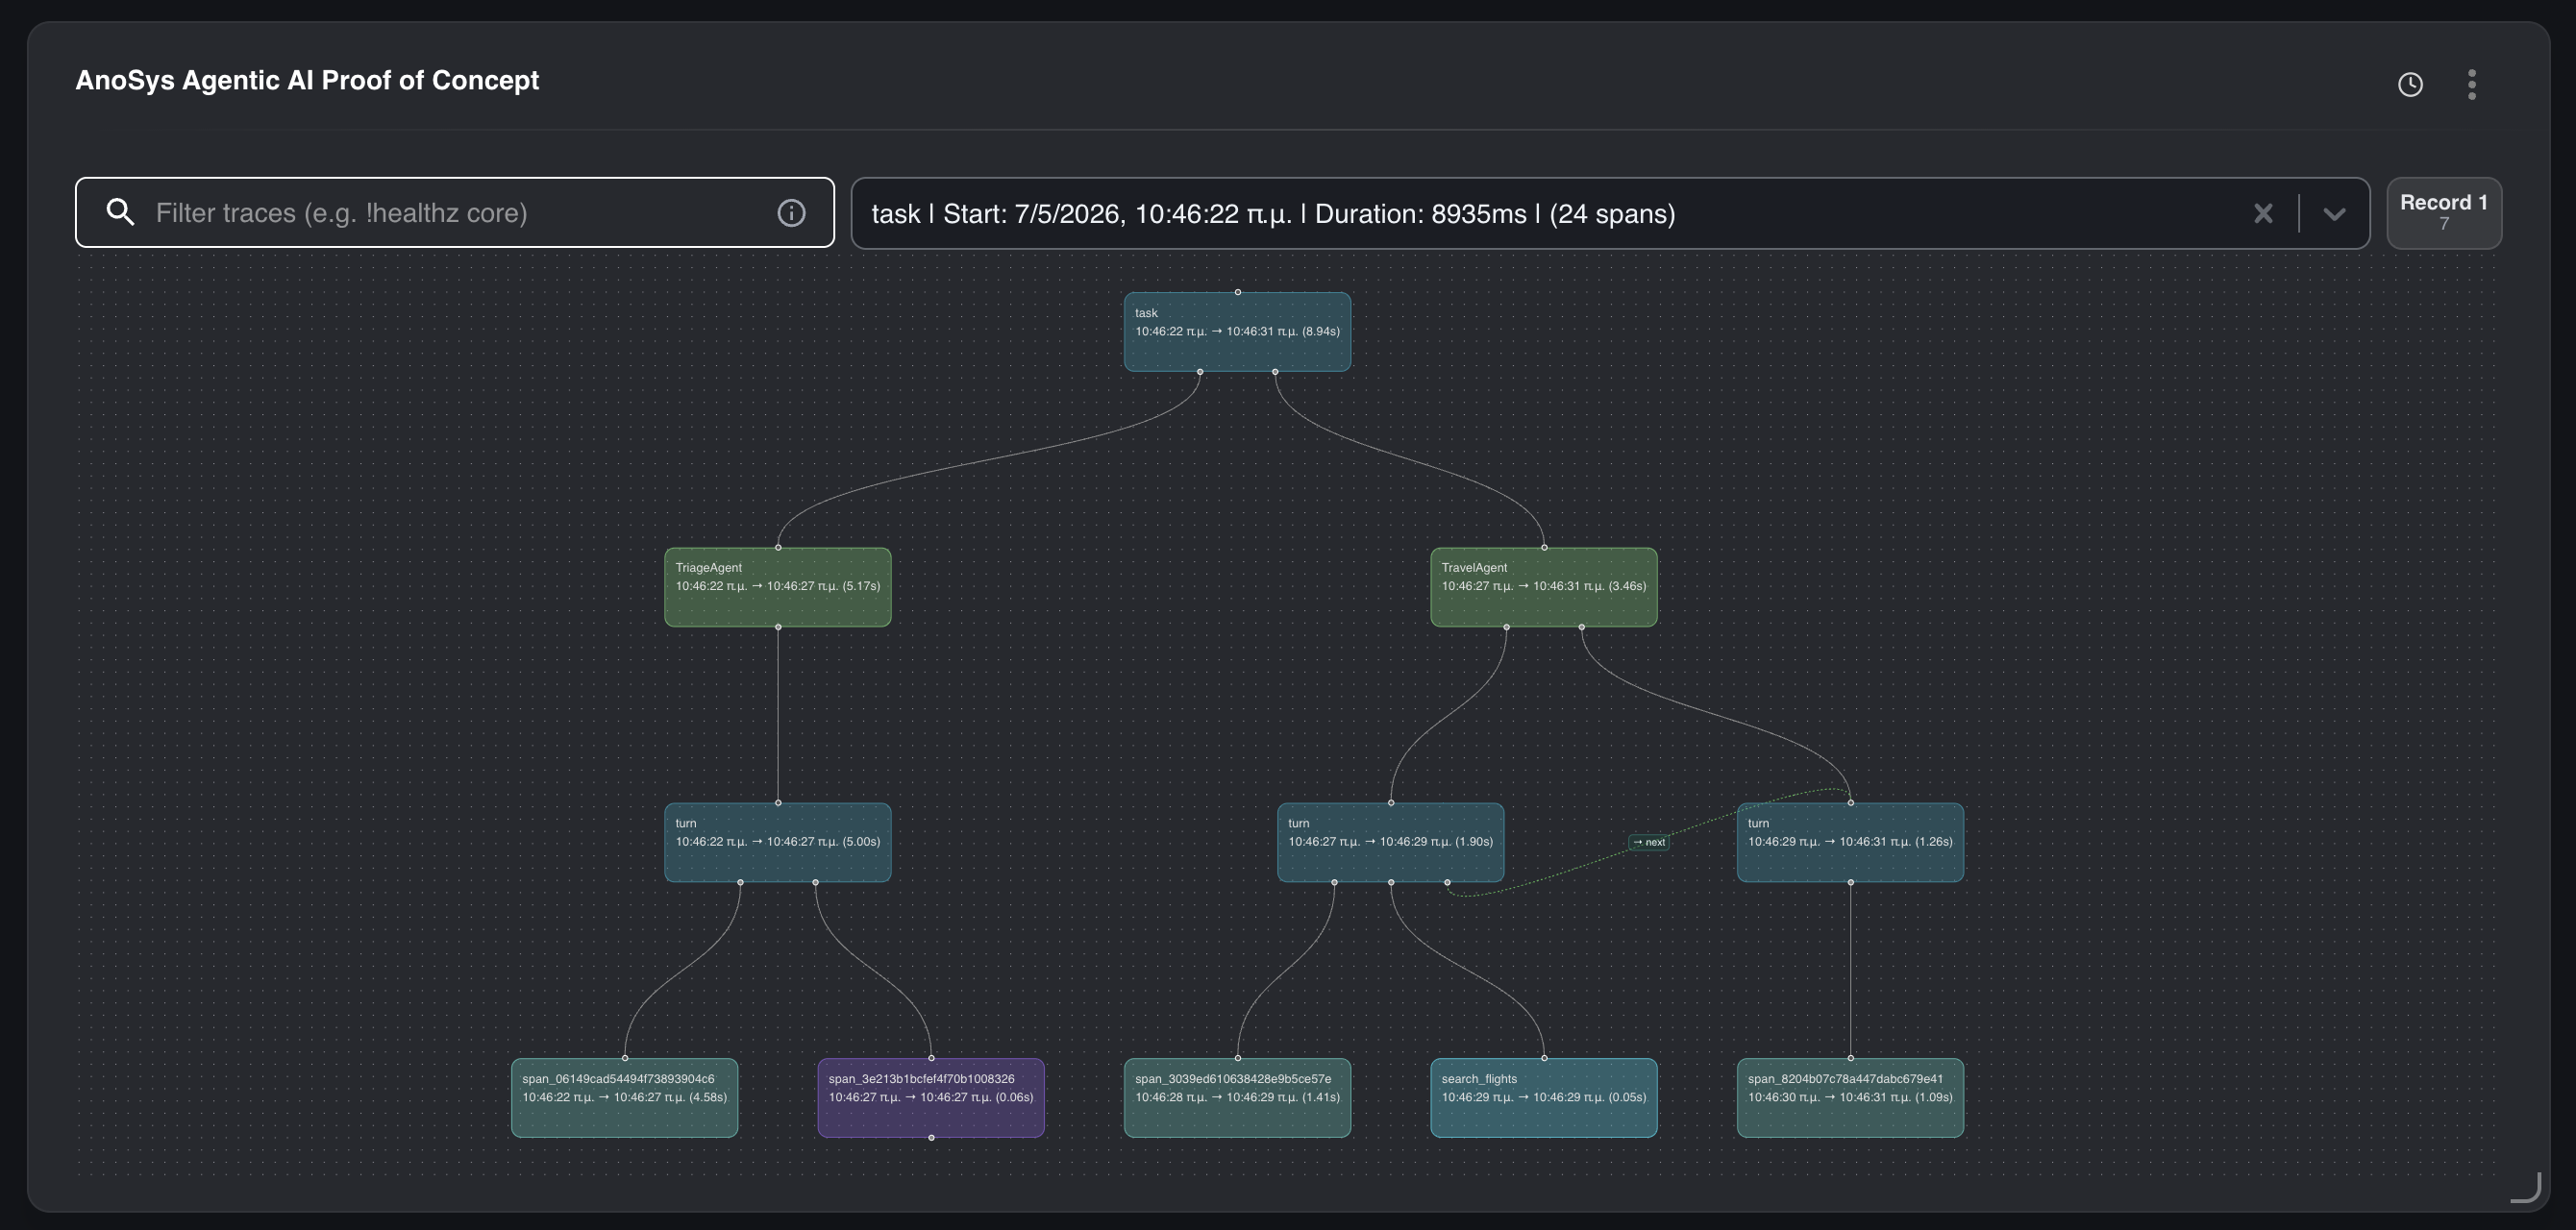

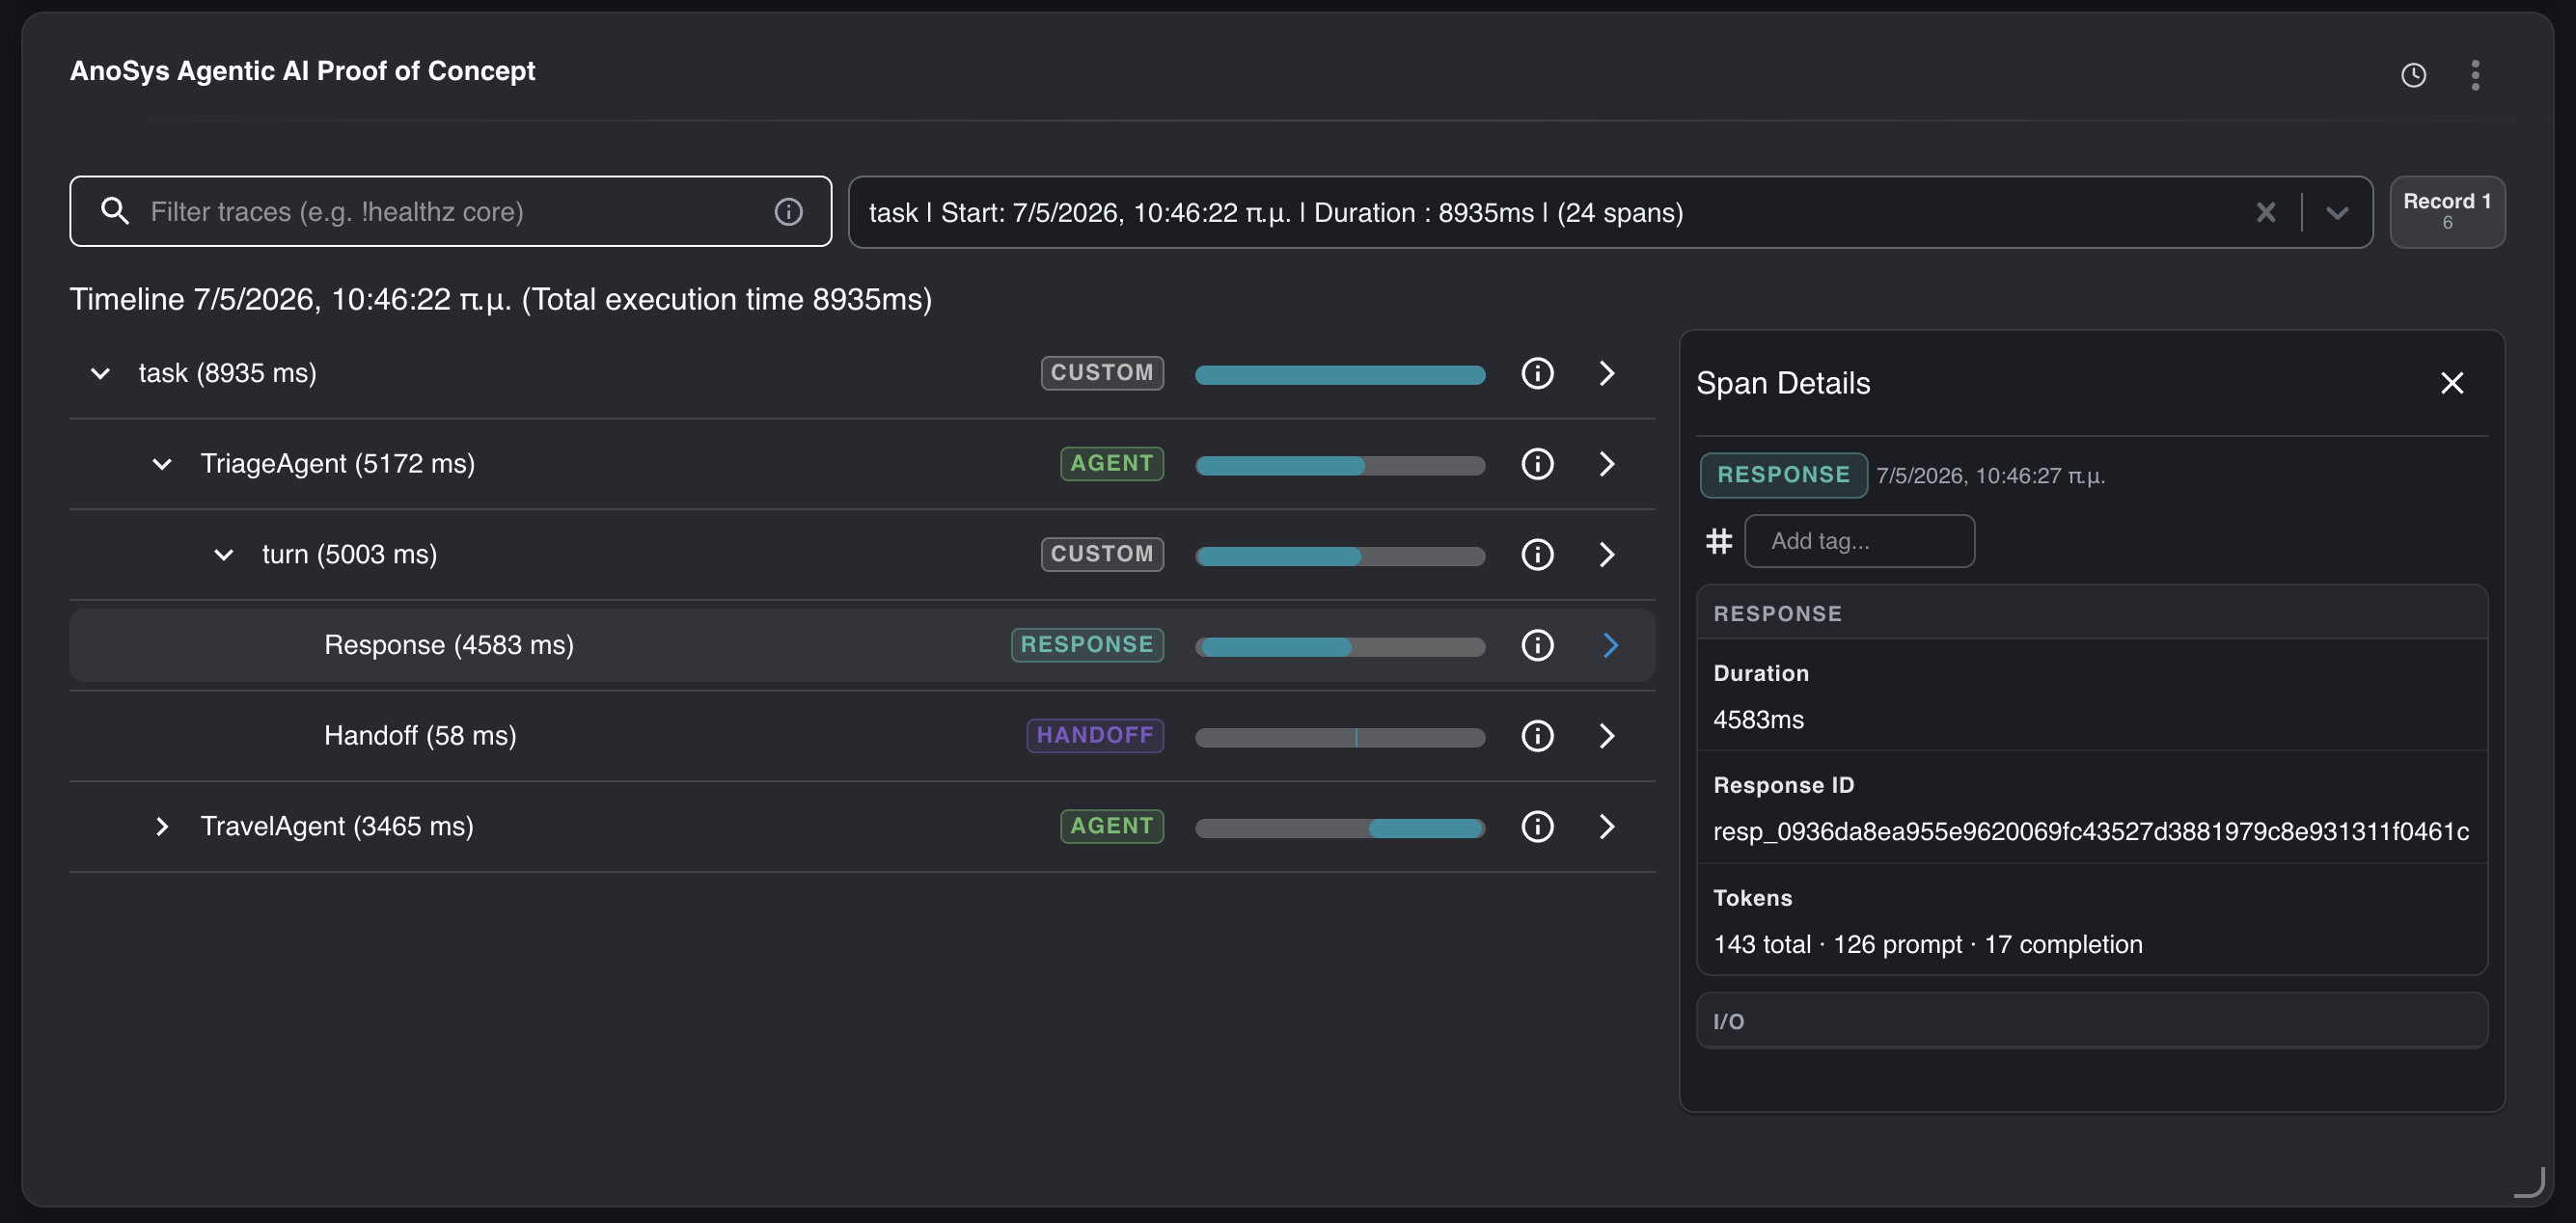